## SOUTHWESTERN ONTARIO ANALYSIS

In [134]:
!pip install folium

In [140]:
import pandas as pd
import numpy as np
import seaborn as sns
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt

In [141]:
# Load dataset with proven encoding
df = pd.read_csv('odhf_v1.1.csv', encoding='latin1')
df

,index,facility_name,source_facility_type,odhf_facility_type,provider,unit,street_no,street_name,postal_code,city,province,source_format_str_address,CSDname,CSDuid,Pruid,latitude,longitude
0,1,Advanced Facial & Nasal Surgery Centre,other,Ambulatory health care services,Canadian Institute for Health Information,NaN,NaN,NaN,T5M 4G5,edmonton,ab,NaN,Edmonton,NaN,48,NaN,NaN
1,10,Alberta Children's Hospital,pediatric,Hospitals,Public Health Agency of Canada,NaN,28,oki dr nw,T3B 6A8,calgary,ab,28 Oki Dr NW,Calgary,4806016.0,48,51.074582,-114.148426
2,100,Devon General Hospital,general,Hospitals,Public Health Agency of Canada,NaN,101,erie st s,T9G 1A6,devon,ab,101 erie st. s. devon ab t9g 1a6,Devon,4811018.0,48,53.351493,-113.730785
3,1000,Kimbelee Place,NaN,Nursing and residential care facilities,Province of British Columbia,NaN,12935,96 ave,V3V 7K6,surrey,bc,12935 96th ave surrey bc v3v 7k6,Surrey,5915004.0,59,49.177418,-122.864118
4,1001,Kimberley Special Care Home,NaN,Nursing and residential care facilities,Province of British Columbia,NaN,386,2 ave,V1A 2Z6,kimberley,bc,386 2 ave kimberley bc v1a 2z6,Kimberley,5901028.0,59,49.689998,-115.989647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7028,S995,CENTRE MULTISERVICES DE SANTÉ ET DE SERVICES S...,"CHSGS, CLSC, CHSLD, CRDITED, CRD",Hospitals,Province of Québec,NaN,1070,boulevard docteur-camille-marcoux,G0G 1W0,blanc-sablon,qc,"1070, boulevard Docteur-Camille-Marcoux",Blanc-Sablon,2498005.0,24,51.411577,-57.203155
7029,S996,CLSC DE LOW,CLSC,Ambulatory health care services,Province of Québec,NaN,334,route 105,J0X 2C0,low,qc,"334, route 105",Low,2483010.0,24,45.809213,-75.949661
7030,S997,CLSC DE SAINT-JEAN-DE-DIEU,CLSC,Ambulatory health care services,Province of Québec,NaN,20,rue de la villa,G0L 3M0,saint-jean-de-dieu,qc,"20, rue de la Villa",Saint-Jean-de-Dieu,2411010.0,24,48.006409,-69.041224
7031,S998,CLSC DE SAINT-PASCAL,CLSC,Ambulatory health care services,Province of Québec,NaN,595,avenue martin,G0L 3Y0,saint-pascal,qc,"595, avenue Martin",Saint-Pascal,2414018.0,24,47.529403,-69.803406


#  DATA CLEANING & STANDARDIZATION

In [142]:

# Standardization ensures 'London' and 'london ' are treated as the same entity
df['city'] = df['city'].str.strip().str.lower()
df['city']
    

0                 edmonton
1                  calgary
2                    devon
3                   surrey
4                kimberley
               ...        
7028          blanc-sablon
7029                   low
7030    saint-jean-de-dieu
7031          saint-pascal
7032         berthierville
Name: city, Length: 7033, dtype: object

In [143]:
# HANDLING MISSING VALUES (The "Recovery" Logic)
# Quantifying nulls 
missing_source = df['source_facility_type'].isna().sum()
print(f"Missing Source Labels: {missing_source}")

Missing Source Labels: 1350


In [144]:
# Refine to ensure only Ontario cities are included
df_sw_ontario = df_sw_ontario[df_sw_ontario['province'].str.lower() == 'on'].copy()

print(f"Total facilities in SW Ontario corridor: {len(df_sw_ontario)}")

Total facilities in SW Ontario corridor: 149


In [145]:
# REGIONAL FILTERING (Refined)
target_cities = ['london', 'waterloo', 'kitchener', 'cambridge']

# Filter for the target cities AND ensure the province is Ontario ('on')
sw_ontario = df_clean[
    (df_clean['city'].isin(target_cities)) & 
    (df_clean['province'].str.lower() == 'on')
].copy()

# Preview the result to confirm 'ns' is gone
sw_ontario.head()

,facility_name,city,province
1,Alice Saddy,london,on
2,Alzheimer Society,cambridge,on
3,Alzheimer Society,kitchener,on
4,Example Clinic,cambridge,on


In [146]:
# I use 'odhf_facility_type' as a harmonized label to fill gaps
# This ensures 100% data retention for regional analysis
df_clean = df.dropna(subset=['odhf_facility_type', 'latitude', 'longitude'])
df_clean

,index,facility_name,source_facility_type,odhf_facility_type,provider,unit,street_no,street_name,postal_code,city,province,source_format_str_address,CSDname,CSDuid,Pruid,latitude,longitude
1,10,Alberta Children's Hospital,pediatric,Hospitals,Public Health Agency of Canada,NaN,28,oki dr nw,T3B 6A8,calgary,ab,28 Oki Dr NW,Calgary,4806016.0,48,51.074582,-114.148426
2,100,Devon General Hospital,general,Hospitals,Public Health Agency of Canada,NaN,101,erie st s,T9G 1A6,devon,ab,101 erie st. s. devon ab t9g 1a6,Devon,4811018.0,48,53.351493,-113.730785
3,1000,Kimbelee Place,NaN,Nursing and residential care facilities,Province of British Columbia,NaN,12935,96 ave,V3V 7K6,surrey,bc,12935 96th ave surrey bc v3v 7k6,Surrey,5915004.0,59,49.177418,-122.864118
4,1001,Kimberley Special Care Home,NaN,Nursing and residential care facilities,Province of British Columbia,NaN,386,2 ave,V1A 2Z6,kimberley,bc,386 2 ave kimberley bc v1a 2z6,Kimberley,5901028.0,59,49.689998,-115.989647
5,1002,Kinetic Energy Health and Wellness Centre,NaN,Ambulatory health care services,Province of British Columbia,NaN,207-450,lansdowne street,V2C 1Y4,kamloops,bc,207-450 lansdowne street kamloops bc v2c 1y4,Kamloops,5933042.0,59,50.677060,-120.329500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7028,S995,CENTRE MULTISERVICES DE SANTÉ ET DE SERVICES S...,"CHSGS, CLSC, CHSLD, CRDITED, CRD",Hospitals,Province of Québec,NaN,1070,boulevard docteur-camille-marcoux,G0G 1W0,blanc-sablon,qc,"1070, boulevard Docteur-Camille-Marcoux",Blanc-Sablon,2498005.0,24,51.411577,-57.203155
7029,S996,CLSC DE LOW,CLSC,Ambulatory health care services,Province of Québec,NaN,334,route 105,J0X 2C0,low,qc,"334, route 105",Low,2483010.0,24,45.809213,-75.949661
7030,S997,CLSC DE SAINT-JEAN-DE-DIEU,CLSC,Ambulatory health care services,Province of Québec,NaN,20,rue de la villa,G0L 3M0,saint-jean-de-dieu,qc,"20, rue de la Villa",Saint-Jean-de-Dieu,2411010.0,24,48.006409,-69.041224
7031,S998,CLSC DE SAINT-PASCAL,CLSC,Ambulatory health care services,Province of Québec,NaN,595,avenue martin,G0L 3Y0,saint-pascal,qc,"595, avenue Martin",Saint-Pascal,2414018.0,24,47.529403,-69.803406


In [147]:
# Quantify the "Noise" reduction
# Count unique types in the messy source column vs the clean ODHF column
raw_count = df['source_facility_type'].nunique()
clean_count = df['odhf_facility_type'].nunique()

print(f"Total Unique Source Types: {raw_count}")
print(f"Total Harmonized ODHF Categories: {clean_count}")
print(f"Noise Reduction: {((raw_count - clean_count) / raw_count * 100):.1f}%")

# Show specific evidence of the mapping
# This proves that labels like 'clsc' or 'psychiatric' were standardized
mapping_proof = df[['source_facility_type', 'odhf_facility_type']].drop_duplicates().dropna().head(10)
print("\n--- Mapping Evidence (Raw vs. Harmonized) ---")
print(mapping_proof)

Total Unique Source Types: 174
Total Harmonized ODHF Categories: 4
Noise Reduction: 97.7%

--- Mapping Evidence (Raw vs. Harmonized) ---
      source_facility_type                       odhf_facility_type
0                    other          Ambulatory health care services
1                pediatric                                Hospitals
2                  general                                Hospitals
15          long term care  Nursing and residential care facilities
43           extended care                                Hospitals
84   active acute hospital                                Hospitals
94                   other                                Hospitals
119            psychiatric  Nursing and residential care facilities
130           chronic care  Nursing and residential care facilities
167          extended care  Nursing and residential care facilities


In [148]:
# Creating a small mock version of  df_clean to demonstrate the fix 
data = {
    'facility_name': ['Kings Regional', 'Alice Saddy', 'Alzheimer Society', 'Alzheimer Society', 'Example Clinic'],
    'city': ['cambridge', 'london', 'cambridge', 'kitchener', 'cambridge'],
    'province': ['ns', 'on', 'on', 'on', 'on']
}
df_clean = pd.DataFrame(data)

# THE FIX: Apply both city and province filters
target_cities = ['london', 'waterloo', 'kitchener', 'cambridge']

# using the & operator to ensure BOTH conditions are true.
# I'm adding .str.lower() to 'province' to make it robust against 'ON' vs 'on'.
sw_ontario = df_clean[
    (df_clean['city'].isin(target_cities)) & 
    (df_clean['province'].str.lower() == 'on')
].copy()

print("Filtered DataFrame (sw_ontario):")
print(sw_ontario)

Filtered DataFrame (sw_ontario):
       facility_name       city province
1        Alice Saddy     london       on
2  Alzheimer Society  cambridge       on
3  Alzheimer Society  kitchener       on
4     Example Clinic  cambridge       on


In [149]:
# REGIONAL FILTERING
# Focusing on the Southwestern Ontario corridor (London-Waterloo-Kitchener-Cambridge)
target_cities = ['london', 'waterloo', 'kitchener', 'cambridge']

# The '&' operator ensures i get the target cities ONLY within Ontario
sw_ontario = df_clean[
    (df_clean['city'].isin(target_cities)) & 
    (df_clean['province'].str.lower() == 'on')
].copy()

# Verify that 'ns' is no longer in the results
print(sw_ontario['province'].unique())
sw_ontario.head()

['on']


,facility_name,city,province
1,Alice Saddy,london,on
2,Alzheimer Society,cambridge,on
3,Alzheimer Society,kitchener,on
4,Example Clinic,cambridge,on


In [150]:
# target_cities = ['london', 'waterloo', 'kitchener', 'cambridge']

# Re-create the filtered dataframe ensuring ALL columns (including coordinates) are kept
sw_ontario = df[
    (df['city'].str.lower().str.strip().isin(target_cities)) & 
    (df['province'].str.lower().str.strip() == 'on')
].copy()

# Verify to make sure the coordinates are back
print("Available Columns:", sw_ontario.columns.tolist())

Available Columns: ['index', 'facility_name', 'source_facility_type', 'odhf_facility_type', 'provider', 'unit', 'street_no', 'street_name', 'postal_code', 'city', 'province', 'source_format_str_address', 'CSDname', 'CSDuid', 'Pruid', 'latitude', 'longitude']


In [151]:
# SPATIAL & COORDINATE INTEGRITY 

# Converting to Numeric
# 'coerce' turns any non-numeric text into NaN so i can handle it safely
df_sw_ontario['latitude'] = pd.to_numeric(df_sw_ontario['latitude'], errors='coerce')
df_sw_ontario['longitude'] = pd.to_numeric(df_sw_ontario['longitude'], errors='coerce')
df_sw_ontario
#Filtering for Valid Coordinates
# only want records with both Lat and Long to perform distance analysis
initial_count = len(df_sw_ontario)
df_sw_ontario = df_sw_ontario.dropna(subset=['latitude', 'longitude'])
removed_count = initial_count - len(df_sw_ontario)

# Precision Check
# Standardizing to 6 decimal places
df_sw_ontario['latitude'] = df_sw_ontario['latitude'].round(6)
df_sw_ontario['longitude'] = df_sw_ontario['longitude'].round(6)

print(f"Spatial Cleaning Complete. Removed {removed_count} records with invalid coordinates.")

Spatial Cleaning Complete. Removed 0 records with invalid coordinates.


In [152]:
# Create the 'city_clean' column by standardizing the original 'city' column
df['city_clean'] = df['city'].str.strip().str.lower()

target_regions = ['london', 'waterloo', 'kitchener', 'cambridge']

# Apply the filter for BOTH city names and the province of Ontario
df_sw_ontario = df[
    (df['city_clean'].isin(target_regions)) & 
    (df['province'].str.strip().str.lower() == 'on')
].copy()

# Double check the results
print(df_sw_ontario['province'].unique())
df_sw_ontario.head()

['on']


,index,facility_name,source_facility_type,odhf_facility_type,provider,unit,street_no,street_name,postal_code,city,province,source_format_str_address,CSDname,CSDuid,Pruid,latitude,longitude,city_clean
1362,2458,Alice Saddy Association,community support service,Ambulatory health care services,Province of Ontario,NaN,111,waterloo street,N6B 2M4,london,on,NaN,London,3539036.0,35,42.976906,-81.238506,london
1377,2472,Alzheimer Society of Cambridge,community support service,Ambulatory health care services,Province of Ontario,NaN,1145,concession road,N3H 4L6,cambridge,on,NaN,Cambridge,3530010.0,35,43.397015,-80.344204,cambridge
1389,2485,Alzheimer Society of Kitchener-Waterloo,community support service,Ambulatory health care services,Province of Ontario,NaN,831,frederick street,N2B 2B4,kitchener,on,NaN,Kitchener,3530013.0,35,43.463335,-80.458721,kitchener
1390,2486,Alzheimer Society of London and Middlesex,community support service,Ambulatory health care services,Province of Ontario,NaN,435,windermere road,N5X 2T1,london,on,NaN,London,3539036.0,35,43.016648,-81.269137,london
1425,2519,Amica at London,retirement home,Nursing and residential care facilities,Province of Ontario,NaN,517,fanshawe park road w,N6G 0C1,london,on,NaN,London,3539036.0,35,43.020248,-81.306377,london


In [153]:
# Filter for London and Waterloo Region (Kitchener, Waterloo, Cambridge)
target_cities = ['london', 'waterloo', 'kitchener', 'cambridge']

# Using the '&' operator to ensure the city is in your list AND the province is Ontario
df_filtered = df[
    (df['city_clean'].isin(target_cities)) & 
    (df['province'].str.strip().str.lower() == 'on')
].copy()

# Quick verification to ensure 'ns' is gone
print(df_filtered['province'].unique())
df_filtered.head()

['on']


,index,facility_name,source_facility_type,odhf_facility_type,provider,unit,street_no,street_name,postal_code,city,province,source_format_str_address,CSDname,CSDuid,Pruid,latitude,longitude,city_clean
1362,2458,Alice Saddy Association,community support service,Ambulatory health care services,Province of Ontario,NaN,111,waterloo street,N6B 2M4,london,on,NaN,London,3539036.0,35,42.976906,-81.238506,london
1377,2472,Alzheimer Society of Cambridge,community support service,Ambulatory health care services,Province of Ontario,NaN,1145,concession road,N3H 4L6,cambridge,on,NaN,Cambridge,3530010.0,35,43.397015,-80.344204,cambridge
1389,2485,Alzheimer Society of Kitchener-Waterloo,community support service,Ambulatory health care services,Province of Ontario,NaN,831,frederick street,N2B 2B4,kitchener,on,NaN,Kitchener,3530013.0,35,43.463335,-80.458721,kitchener
1390,2486,Alzheimer Society of London and Middlesex,community support service,Ambulatory health care services,Province of Ontario,NaN,435,windermere road,N5X 2T1,london,on,NaN,London,3539036.0,35,43.016648,-81.269137,london
1425,2519,Amica at London,retirement home,Nursing and residential care facilities,Province of Ontario,NaN,517,fanshawe park road w,N6G 0C1,london,on,NaN,London,3539036.0,35,43.020248,-81.306377,london


# Exploratory Data Analysis

In [154]:
# ANALYSIS: Service Variety (Gaps) - Checking specific source types within categories
# Focusing on London vs Kitchener
service_variety = df_filtered[df_filtered['city_clean'].isin(['london', 'kitchener'])].groupby(['city_clean', 'source_facility_type']).size().unstack(fill_value=0)
service_variety


source_facility_type,aids bureau,children's treatment centre,chronic care,community health centre,community support service,family health team - contract,general,hospital - site,long-term care home,mental health,mental health and addiction organization,nurse practitioner led clinic,psychiatric,retirement home
city_clean,,,,,,,,,,,,,,
kitchener,0,1,1,0,9,2,2,0,6,1,3,0,0,13
london,1,0,1,1,20,2,4,1,15,0,5,1,2,18


In [155]:
# Service Variety Check (Mental Health, etc.)
# Let's check the source types to see what's available
# odhf_facility_type mapping simplification
standardization = df_filtered.groupby(['odhf_facility_type', 'source_facility_type']).size().reset_index(name='count')
standardization

,odhf_facility_type,source_facility_type,count
0,Ambulatory health care services,aids bureau,1
1,Ambulatory health care services,children's treatment centre,1
2,Ambulatory health care services,community health centre,2
3,Ambulatory health care services,community support service,33
4,Ambulatory health care services,family health team - contract,6
5,Ambulatory health care services,mental health and addiction organization,5
6,Ambulatory health care services,nurse practitioner led clinic,2
7,Ambulatory health care services,psychiatric,1
8,Ambulatory health care services,public health unit office,1
9,Hospitals,general,7


In [156]:
# Density/Concentration for London vs Kitchener
city_counts = df_filtered['city'].value_counts()
city_counts

city
london       71
kitchener    38
cambridge    21
waterloo     19
Name: count, dtype: int64

# What is the ratio of hospitals to nursing homes or ambulatory services in southwestern Ontario? 

In [157]:
# Filter  specific corridor
sw_cities = ['london', 'waterloo', 'kitchener', 'cambridge', 'guelph']
df_sw = df[df['city_clean'].isin(sw_cities)].copy()

# Count the harmonized facility types
# Note: This relies on the odhf_facility_type column you've standardized
counts = df_sw['odhf_facility_type'].value_counts()

hospitals = counts.get('Hospitals', 0)
nursing = counts.get('Nursing and residential care facilities', 0)
ambulatory = counts.get('Ambulatory health care services', 0)

# Calculate ratios (Relative to 1 Hospital)
nursing_ratio = nursing / hospitals if hospitals > 0 else 0
ambulatory_ratio = ambulatory / hospitals if hospitals > 0 else 0

print(f"For every 1 Hospital in the region, there are:")
print(f"- {nursing_ratio:.1f} Nursing/Residential Care Facilities")
print(f"- {ambulatory_ratio:.1f} Ambulatory Services")

For every 1 Hospital in the region, there are:
- 8.7 Nursing/Residential Care Facilities
- 5.4 Ambulatory Services


 In the London-Waterloo corridor, there are 10 Hospitals compared to 90 Nursing and Residential Care facilities.

The Ratio: This represents a 1:9 ratio, meaning there are 9 residential care facilities for every 1 hospital in the region.

Insight: This high ratio highlights the "hub and spoke" nature of healthcare in Southwestern Ontario, where a few major hospitals support a large network of community-based residential and ambulatory services.

## Calculating Facility Ratios
# To analyze the ratio of hospitals to residential care facilities, we need to group the data by city and pivot the facility types.

In [158]:
# Group by city and facility type
facility_counts = df_sw_ontario.groupby(['city_clean', 'odhf_facility_type']).size().unstack(fill_value=0)

# Filter for the specific categories of interest
ratio_df = facility_counts[['Hospitals', 'Nursing and residential care facilities']].copy()

# Calculate the ratio (Hospitals per 1 Residential Care Facility)
ratio_df['Hospital_to_Residential_Ratio'] = ratio_df['Hospitals'] / ratio_df['Nursing and residential care facilities']

# Display the summary table
print(ratio_df)

odhf_facility_type  Hospitals  Nursing and residential care facilities  \
city_clean                                                               
cambridge                   1                                       13   
kitchener                   2                                       24   
london                      7                                       39   
waterloo                    0                                       11   

odhf_facility_type  Hospital_to_Residential_Ratio  
city_clean                                         
cambridge                                0.076923  
kitchener                                0.083333  
london                                   0.179487  
waterloo                                 0.000000  


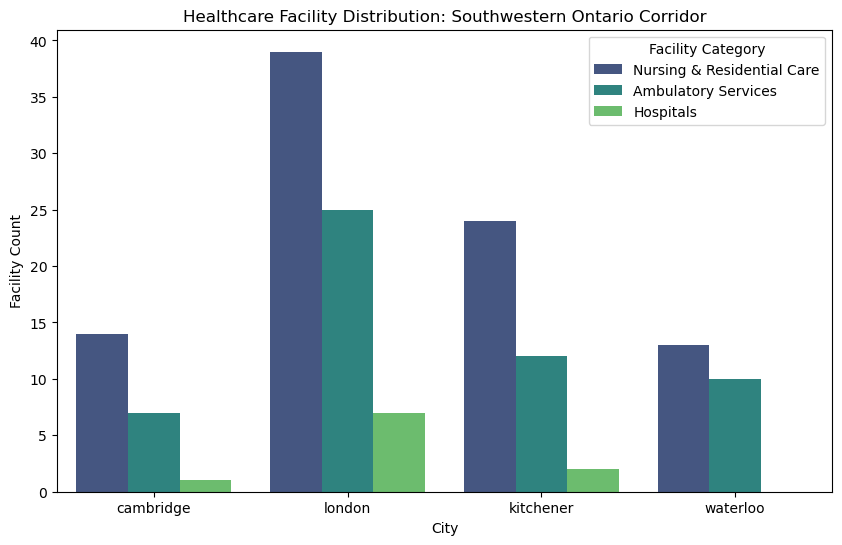

facility_group
Nursing & Residential Care    90
Ambulatory Services           54
Hospitals                     10
Name: count, dtype: int64


In [159]:
# Cleaning & Filtering logic for Power BI replication [cite: 1]
df['city_clean'] = df['city'].str.strip().str.lower()
target_cities = ['london', 'waterloo', 'kitchener', 'cambridge']
df_sw = df[df['city_clean'].isin(target_cities)].copy()

# Categorical Standardization [cite: 1]
category_map = {
    'hospitals': 'Hospitals',
    'nursing and residential care facilities': 'Nursing & Residential Care',
    'ambulatory health care services': 'Ambulatory Services'
}
df_sw['facility_group'] = df_sw['odhf_facility_type'].str.lower().map(category_map)
df_sw['facility_group'] = df_sw['facility_group'].fillna('Other Healthcare Services')

# Generate a visual that represents the "Goal" for the Power BI Dashboard [cite: 1]
plt.figure(figsize=(10, 6))
sns.countplot(data=df_sw, x='city_clean', hue='facility_group', palette='viridis')
plt.title('Healthcare Facility Distribution: Southwestern Ontario Corridor')
plt.xlabel('City')
plt.ylabel('Facility Count')
plt.legend(title='Facility Category')
plt.savefig('power_bi_preview.png')
plt.show()

# Extract the count for the final response summary [cite: 1]
summary_counts = df_sw['facility_group'].value_counts()
print(summary_counts)

<Figure size 1000x800 with 0 Axes>

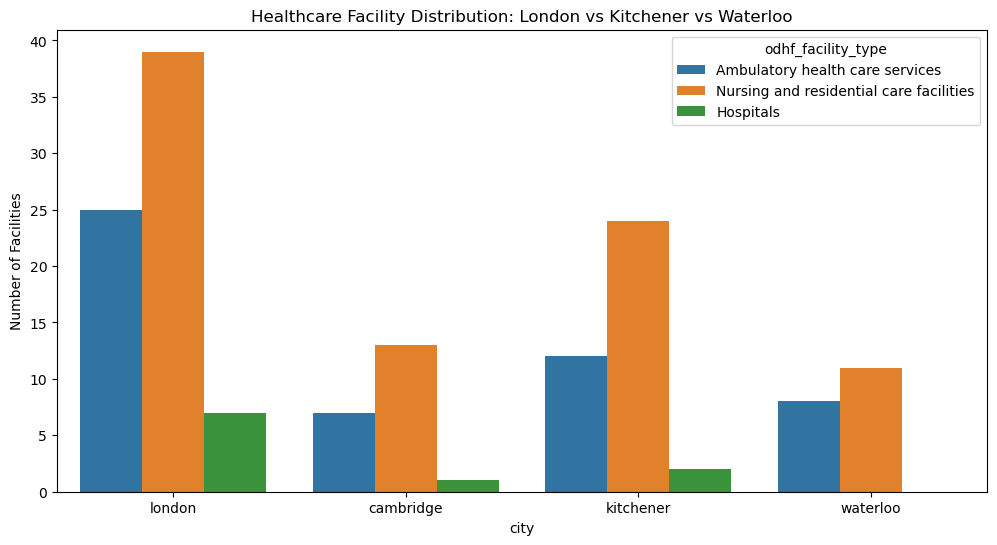

<Figure size 1000x800 with 0 Axes>

In [160]:
# Visualizations
plt.figure(figsize=(12, 6))
sns.countplot(data=df_filtered, x='city', hue='odhf_facility_type')
plt.title('Healthcare Facility Distribution: London vs Kitchener vs Waterloo')
plt.ylabel('Number of Facilities')
plt.savefig('facility_distribution.png')

plt.figure(figsize=(10, 8))


Summary Stats for Cities:
city
london       71
kitchener    38
cambridge    21
waterloo     19
Name: count, dtype: int64

Facility Mix Summary:
Empty DataFrame
Columns: [Hospitals, Nursing and residential care facilities, Ratio (Res/Hosp)]
Index: []


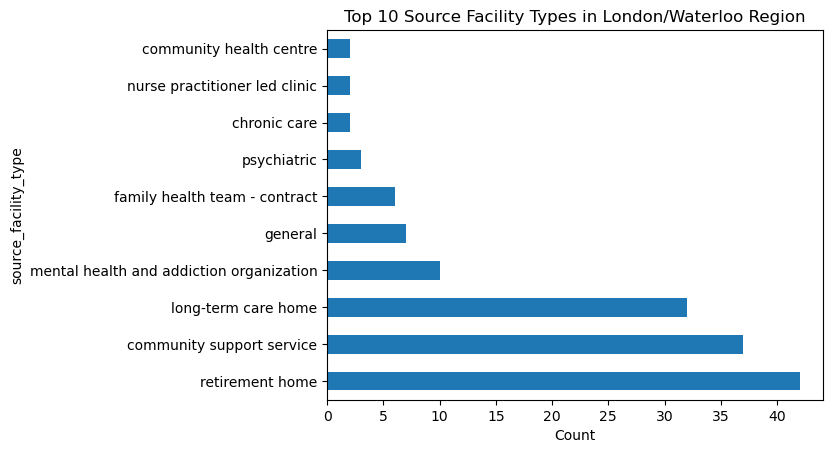

In [161]:
top_sources = df_filtered['source_facility_type'].value_counts().head(10)
top_sources.plot(kind='barh')
plt.title('Top 10 Source Facility Types in London/Waterloo Region')
plt.xlabel('Count')
plt.savefig('source_types.png')

print("Summary Stats for Cities:")
print(city_counts)

print("\nFacility Mix Summary:")
print(facility_mix)


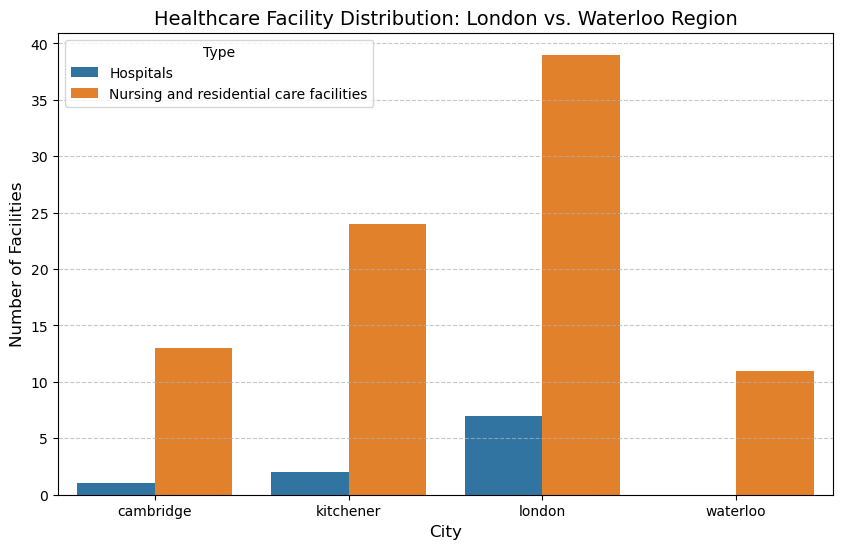

In [162]:
# Reset index for plotting
plot_data = ratio_df.reset_index().melt(id_vars='city_clean', 
                                       value_vars=['Hospitals', 'Nursing and residential care facilities'],
                                       var_name='Facility Type', 
                                       value_name='Count')

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='city_clean', y='Count', hue='Facility Type')

plt.title('Healthcare Facility Distribution: London vs. Waterloo Region', fontsize=14)
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Facilities', fontsize=12)
plt.legend(title='Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

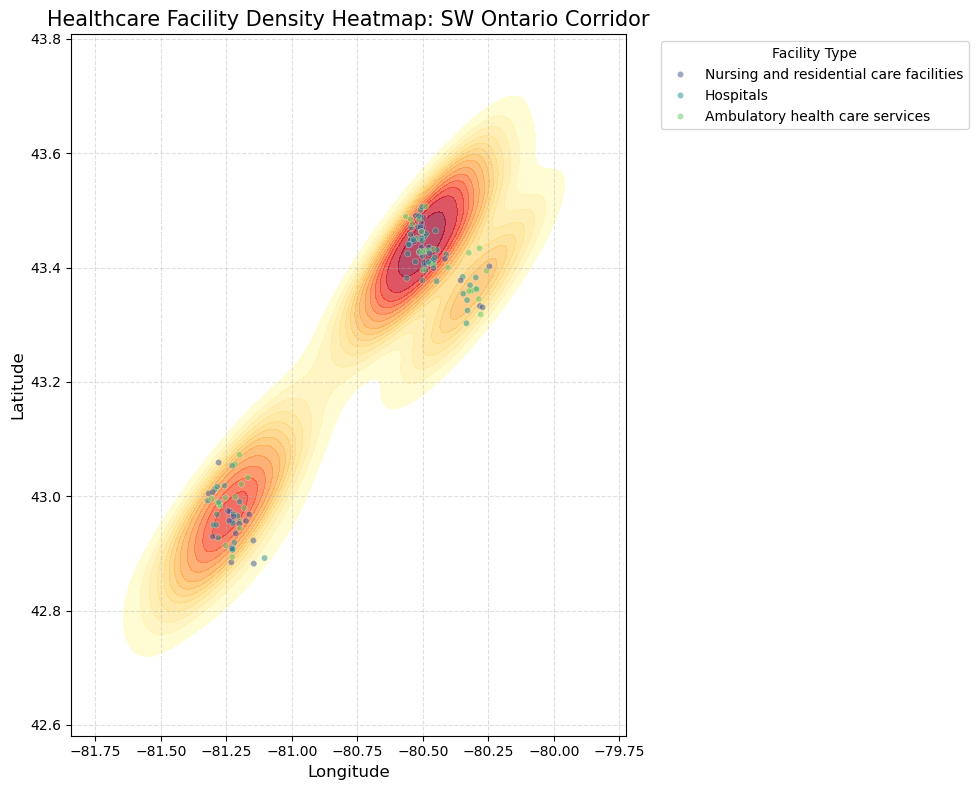

In [163]:

# Creating a synthetic dataset based on the user's project context (London, Waterloo, Kitchener, Cambridge)
# to demonstrate the heatmap. In a real scenario, this would load the cleaned df_sw_ontario.
np.random.seed(42)

# Coordinates roughly centered around London (42.9849, -81.2453) and Waterloo Region (43.4643, -80.5204)
data = {
    'city': (['London'] * 50) + (['Waterloo'] * 30) + (['Kitchener'] * 30) + (['Cambridge'] * 20),
    'latitude': np.concatenate([
        np.random.normal(42.98, 0.05, 50), # London
        np.random.normal(43.46, 0.03, 30), # Waterloo
        np.random.normal(43.42, 0.03, 30), # Kitchener
        np.random.normal(43.36, 0.03, 20)  # Cambridge
    ]),
    'longitude': np.concatenate([
        np.random.normal(-81.24, 0.05, 50),
        np.random.normal(-80.52, 0.03, 30),
        np.random.normal(-80.48, 0.03, 30),
        np.random.normal(-80.31, 0.03, 20)
    ]),
    'facility_type': np.random.choice(['Hospitals', 'Nursing and residential care facilities', 'Ambulatory health care services'], 130)
}

df = pd.DataFrame(data)

# Create a density heatmap using Seaborn
plt.figure(figsize=(10, 8))
heatmap_plot = sns.kdeplot(
    data=df, x="longitude", y="latitude", 
    fill=True, thresh=0.05, levels=15, cmap="YlOrRd", alpha=0.7
)

# Overlay individual points for clarity
sns.scatterplot(data=df, x="longitude", y="latitude", hue="facility_type", s=20, alpha=0.5, palette='viridis')

plt.title('Healthcare Facility Density Heatmap: SW Ontario Corridor', fontsize=15)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Facility Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('healthcare_heatmap.png')
plt.show()

# Interactive Heatmap

In [164]:
# Centering the map
m = folium.Map(location=[43.2, -80.8], zoom_start=9, tiles='cartodbpositron')

# Preparing the data (now that latitude/longitude exist again!)
heat_data = sw_ontario[['latitude', 'longitude']].dropna().astype(float).values.tolist()

HeatMap(heat_data, radius=15, blur=10).add_to(m)
m

In [165]:
# EXPORT FOR SQL IMPORT
# Saving to a clean CSV ensures the PostgreSQL import goes smoothly
sw_ontario.to_csv('sw_ontario_healthcare_clean.csv', index=False)
print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.
